# Phase 3: Advanced Edge Refinement Pipeline

In this notebook, we implement and compare two edge refinement techniques:
1. **Coarse Segmentation:** Get a rough mask of the foreground using **BiRefNet**.
2. **Automatic Trimap Generation:** Calculate a transition boundary (eroded vs dilated masks) to identify uncertain edge pixels.
3. **Classical Edge Refinement:** **Guided Filter** to smooth out boundaries using high-frequency details from the original image.
4. **Deep Learning Edge Refinement (SOTA):** **ViTMatte** (Vision Transformer for Image Matting) which takes the original image and the generated trimap to predict a high-fidelity alpha matte.

In [6]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoModelForImageSegmentation, AutoImageProcessor, VitMatteForImageMatting

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Load Models
We load both **BiRefNet** (for coarse mask) and **ViTMatte** (for advanced edge matting).

In [7]:
print("Loading BiRefNet model...")
birefnet_model = AutoModelForImageSegmentation.from_pretrained("ZhengPeng7/BiRefNet", trust_remote_code=True)
birefnet_model.to(device)
birefnet_model.eval()

print("Loading ViTMatte model and processor...")
vitmatte_id = "hustvl/vitmatte-base-composition-1k"
vitmatte_processor = AutoImageProcessor.from_pretrained(vitmatte_id)
vitmatte_model = VitMatteForImageMatting.from_pretrained(vitmatte_id, weights_only=False)
vitmatte_model.to(device)
vitmatte_model.eval()

print("All models loaded successfully!")

Loading BiRefNet model...
Loading ViTMatte model and processor...


`self.size_divisibility` attribute is deprecated and will be removed in v5. Use `self.size_divisor` instead


All models loaded successfully!


## Pipeline Helper Functions

### 1. Preprocessing and Coarse Prediction
Runs the input image through BiRefNet to produce the base probability mask.

### 2. Automatic Trimap Generation
We use PyTorch's native `max_pool2d` to perform Morphological Dilation and Erosion on the GPU, avoiding external library dependencies like OpenCV or Scipy.

### 3. Guided Image Filtering
Performs edge-preserving smoothing on the coarse mask using the grayscale original image as the guide.

In [8]:
def get_coarse_mask(image_path):
    input_image = Image.open(image_path).convert("RGB")
    original_size = input_image.size

    transform = transforms.Compose([
        transforms.Resize((1024, 1024)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    input_tensor = transform(input_image).unsqueeze(0).to(device)

    with torch.no_grad():
        preds = birefnet_model(input_tensor)[-1].sigmoid()
    return input_image, preds

def generate_trimap(mask_tensor, kernel_size=15):
    padding = kernel_size // 2
    
    # Dilation (Max Pool)
    dilated = F.max_pool2d(mask_tensor, kernel_size=kernel_size, stride=1, padding=padding)
    
    # Erosion (Min Pool = 1 - Max Pool of 1 - mask)
    eroded = 1.0 - F.max_pool2d(1.0 - mask_tensor, kernel_size=kernel_size, stride=1, padding=padding)
    
    # Trimap levels:
    # 0.0 -> Background
    # 0.5 -> Transition/Unknown region
    # 1.0 -> Foreground
    trimap = torch.where(eroded > 0.5, torch.tensor(1.0).to(device), torch.tensor(0.5).to(device))
    trimap = torch.where(dilated < 0.5, torch.tensor(0.0).to(device), trimap)
    return trimap

def guided_filter_gray(guide_tensor, input_mask_tensor, r=8, eps=1e-4):
    # Convert guide tensor to grayscale if it is RGB
    if guide_tensor.shape[1] == 3:
        I = 0.299 * guide_tensor[:, 0:1, :, :] + 0.587 * guide_tensor[:, 1:2, :, :] + 0.114 * guide_tensor[:, 2:3, :, :]
    else:
        I = guide_tensor
        
    p = input_mask_tensor
    
    def box_filter(x, r):
        kh = kw = 2 * r + 1
        return F.avg_pool2d(x, kernel_size=(kh, kw), stride=1, padding=r)
        
    N = box_filter(torch.ones_like(p), r)
    
    mean_I = box_filter(I, r) / N
    mean_p = box_filter(p, r) / N
    mean_Ip = box_filter(I * p, r) / N
    
    cov_Ip = mean_Ip - mean_I * mean_p
    
    mean_II = box_filter(I * I, r) / N
    var_I = mean_II - mean_I * mean_I
    
    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I
    
    mean_a = box_filter(a, r) / N
    mean_b = box_filter(b, r) / N
    
    q = mean_a * I + mean_b
    return torch.clamp(q, 0.0, 1.0)

print("Pipeline helper functions successfully defined.")

Pipeline helper functions successfully defined.


## Run the Refinement Pipeline

Let's run the pipeline on `test.png` using BiRefNet, automatic Trimap generation, Guided Filter, and ViTMatte.

In [9]:
image_path = "img1 (2).jpg"

# 1. Get image and coarse prediction
original_image, coarse_mask_tensor = get_coarse_mask(image_path)
original_size = original_image.size

# 2. Prepare guide tensor from original image for Guided Filter
guide_transform = transforms.Compose([
    transforms.Resize((1024, 1024)),
    transforms.ToTensor()
])
guide_tensor = guide_transform(original_image).unsqueeze(0).to(device)

# 3. Generate Trimap
trimap_tensor = generate_trimap(coarse_mask_tensor, kernel_size=25)

# 4. Apply Classical Guided Filter to the mask
guided_mask_tensor = guided_filter_gray(guide_tensor, coarse_mask_tensor, r=12, eps=1e-4)

# 5. Convert Trimap back to PIL for ViTMatte
trimap_pil = transforms.ToPILImage()(trimap_tensor[0].cpu()).resize(original_size)

# 6. Apply SOTA ViTMatte Refinement
print("Running ViTMatte refinement...")

# Resize high-res images to a max dimension to prevent CUDA OOM
MAX_SIZE = 1024
w, h = original_size
if max(w, h) > MAX_SIZE:
    scale = MAX_SIZE / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    # Ensure dimensions are divisible by 32 (required by VitDet backbone)
    new_w = max(32, (new_w // 32) * 32)
    new_h = max(32, (new_h // 32) * 32)
    
    vitmatte_image = original_image.resize((new_w, new_h), Image.Resampling.BILINEAR)
    vitmatte_trimap = trimap_pil.resize((new_w, new_h), Image.Resampling.NEAREST)
    print(f"Resized image from {original_size} to {(new_w, new_h)} for ViTMatte to prevent OOM")
else:
    vitmatte_image = original_image
    vitmatte_trimap = trimap_pil

inputs = vitmatte_processor(images=vitmatte_image, trimaps=vitmatte_trimap, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = vitmatte_model(**inputs)
vitmatte_mask_tensor = outputs.alphas

# 7. Post-process masks back to PIL
coarse_mask = transforms.ToPILImage()(coarse_mask_tensor[0].cpu()).resize(original_size)
guided_mask = transforms.ToPILImage()(guided_mask_tensor[0].cpu()).resize(original_size)
vitmatte_mask = transforms.ToPILImage()(vitmatte_mask_tensor[0].cpu()).resize(original_size, Image.Resampling.BILINEAR)

# 8. Generate final cutouts
coarse_cutout = original_image.copy()
coarse_cutout.putalpha(coarse_mask)

guided_cutout = original_image.copy()
guided_cutout.putalpha(guided_mask)

vitmatte_cutout = original_image.copy()
vitmatte_cutout.putalpha(vitmatte_mask)

print("Inference and refinement steps completed!")

Running ViTMatte refinement...
Resized image from (3000, 4000) to (768, 1024) for ViTMatte to prevent OOM
Inference and refinement steps completed!


## Visualize Pipeline Outputs & Save Results

Below, we display each intermediate stage and compare the classic Guided Filter against ViTMatte.

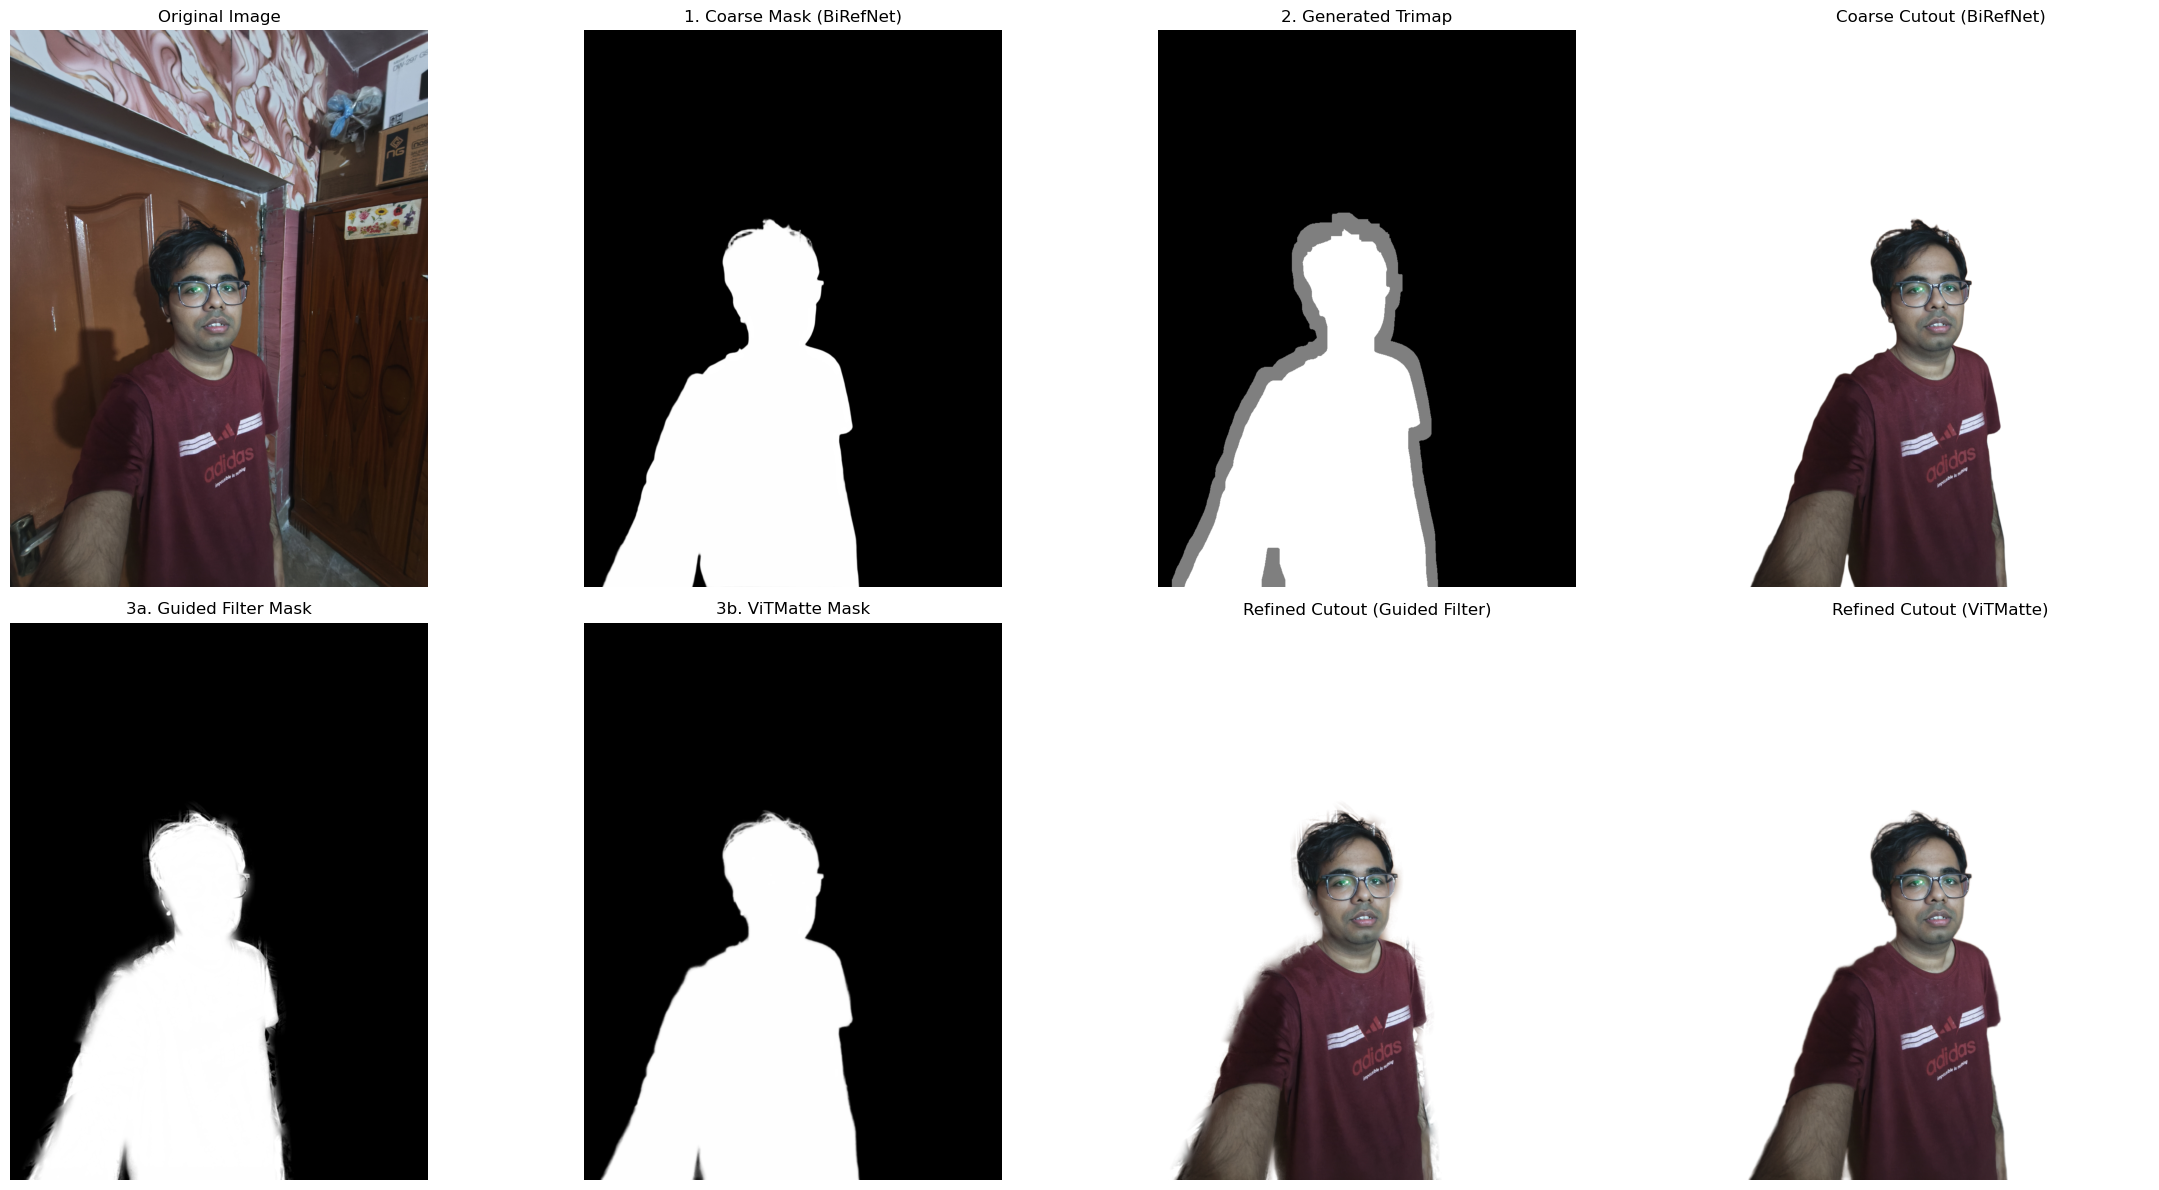

Saved final refined images inside: pipeline_out/


In [10]:
fig, ax = plt.subplots(2, 4, figsize=(24, 12))

# Row 1: Original and inputs
ax[0, 0].imshow(original_image)
ax[0, 0].set_title("Original Image")
ax[0, 0].axis("off")

ax[0, 1].imshow(coarse_mask, cmap='gray')
ax[0, 1].set_title("1. Coarse Mask (BiRefNet)")
ax[0, 1].axis("off")

ax[0, 2].imshow(trimap_pil, cmap='gray')
ax[0, 2].set_title("2. Generated Trimap")
ax[0, 2].axis("off")

ax[0, 3].imshow(coarse_cutout)
ax[0, 3].set_title("Coarse Cutout (BiRefNet)")
ax[0, 3].axis("off")

# Row 2: Refinements & comparisons
ax[1, 0].imshow(guided_mask, cmap='gray')
ax[1, 0].set_title("3a. Guided Filter Mask")
ax[1, 0].axis("off")

ax[1, 1].imshow(vitmatte_mask, cmap='gray')
ax[1, 1].set_title("3b. ViTMatte Mask")
ax[1, 1].axis("off")

ax[1, 2].imshow(guided_cutout)
ax[1, 2].set_title("Refined Cutout (Guided Filter)")
ax[1, 2].axis("off")

ax[1, 3].imshow(vitmatte_cutout)
ax[1, 3].set_title("Refined Cutout (ViTMatte)")
ax[1, 3].axis("off")

plt.tight_layout()
plt.show()

# Save both refined results inside the output directory
import os
output_dir = "pipeline_out"
os.makedirs(output_dir, exist_ok=True)

guided_cutout.save(os.path.join(output_dir, "refined_guided.png"))
vitmatte_cutout.save(os.path.join(output_dir, "refined_vitmatte.png"))

print(f"Saved final refined images inside: {output_dir}/")